In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torchvision
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm
from PIL import Image
import shutil

In [2]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### Path to photos

In [3]:
# Define dataset paths
photo_json_path = "E:/Yelp-Photos/Yelp Photos/photos.json"  # Path to sampled metadata
photos_dir = "E:/Yelp-Photos/Yelp Photos/photos"  # Directory with sampled images
balanced_images_dir = "E:/Yelp-Photos/balanced_photos"  # New directory for balanced subset

In [4]:
# Load the sampled dataset metadata
df_photos = pd.read_json(photo_json_path, lines=True)
print("Total images in sampled dataset:", len(df_photos))

Total images in sampled dataset: 200100


In [5]:
df_photos.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [6]:
df_photos['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [7]:
# Encode labels
label_encoder = LabelEncoder()
df_photos['label'] = label_encoder.fit_transform(df_photos['label'])

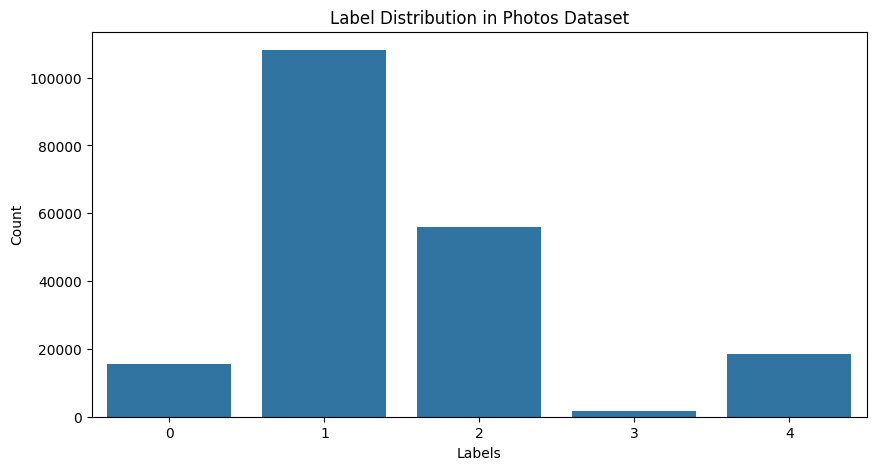

In [8]:
# Check data distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df_photos['label'])
plt.title("Label Distribution in Photos Dataset")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()

In [9]:
# Find the minimum class count for balancing
min_samples_per_class = df_photos['label'].value_counts().min()
print(f"Using {min_samples_per_class} samples per class for balancing.")

Using 1678 samples per class for balancing.


In [10]:
total_target_size = 20000
num_classes = df_photos['label'].nunique()
samples_per_class = min(df_photos['label'].value_counts().min(), total_target_size // num_classes)

print(f"Using {samples_per_class} samples per class for balancing.")

# Sample equal number of images per class
df_balanced = df_photos.groupby('label').apply(lambda x: x.sample(n=samples_per_class, random_state=42))
df_balanced = df_balanced.reset_index(drop=True)

print(f"Final balanced dataset size: {len(df_balanced)} images.")


Using 1678 samples per class for balancing.
Final balanced dataset size: 8390 images.


C:\Users\Admin\AppData\Local\Temp\ipykernel_13196\914768732.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_photos.groupby('label').apply(lambda x: x.sample(n=samples_per_class, random_state=42))


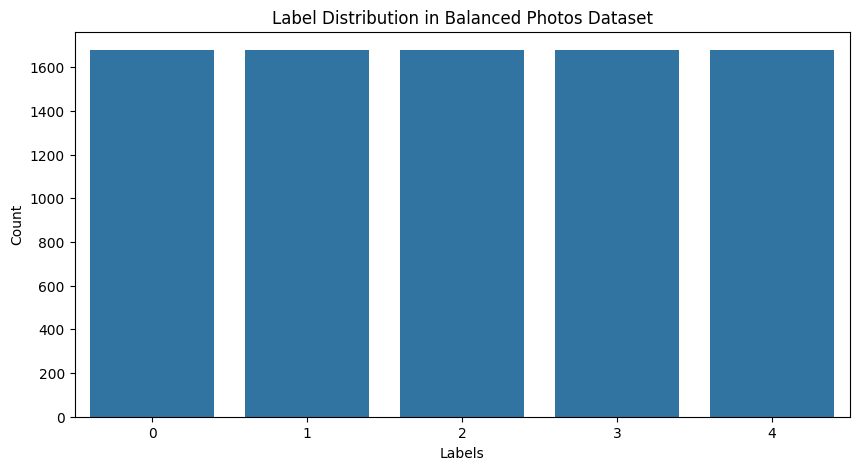

In [11]:
# Check balanced data distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df_balanced['label'])
plt.title("Label Distribution in Balanced Photos Dataset")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()

In [12]:
# Create a directory for the balanced dataset
balanced_images_dir="E:/Yelp-Photos/balanced_photos"
os.makedirs(balanced_images_dir, exist_ok=True)

# Copy balanced images to the new directory
for photo_id in df_balanced['photo_id']:
    src_path = os.path.join(photos_dir, f"{photo_id}.jpg")
    dst_path = os.path.join(balanced_images_dir, f"{photo_id}.jpg")
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)

# Save the balanced metadata
df_balanced.to_json("E:/Yelp-Photos/balanced_photos.json", orient="records", lines=True)

print(f"Balanced subset created with {len(df_balanced)} images.")

# Define dataset paths for processing
data_dir = "E:/Yelp-Photos/balanced_photos"
json_path = "E:/Yelp-Photos/balanced_photos.json"

Balanced subset created with 8390 images.


### Loading from balance data as well as preprocessing

In [13]:
# Load balanced metadata
df_balanced_metadata = pd.read_json(json_path, lines=True)
print("Balanced dataset size:", len(df_balanced_metadata))

# Preprocessing: Load, Apply Gaussian Blur & Histogram Equalization, and Normalize Images
image_size = (64, 64)

def preprocess_image(image_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError("Image not found or cannot be read")
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convert to grayscale
        img = cv2.GaussianBlur(img, (5, 5), 0)  # Apply Gaussian Blur
        img = cv2.equalizeHist(img)  # Apply Histogram Equalization
        img = cv2.resize(img, image_size)  # Resize
        img = img / 255.0  # Normalize
        return img
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

def load_images(df, data_dir, limit=20000):
    images, labels = [], []
    count, error_count = 0, 0
    for _, row in tqdm(df.iterrows(), total=len(df)):
        if count >= limit:
            break
        img_path = os.path.join(data_dir, f"{row['photo_id']}.jpg")
        if os.path.exists(img_path):
            img = preprocess_image(img_path)
            if img is not None:
                images.append(img)
                labels.append(row['label'])
                count += 1
            else:
                error_count += 1
    print(f"Total successfully loaded images: {count}")
    print(f"Total failed images: {error_count}")
    return np.array(images).reshape(-1, 64, 64, 1), np.array(labels)

X, y = load_images(df_balanced_metadata, data_dir, limit=20000)

Balanced dataset size: 8390


 23%|████████████████                                                     | 1948/8390 [00:26<01:41, 63.69it/s]

Error processing image E:/Yelp-Photos/balanced_photos\l_rMdwgrvjm2PyHyXBcBTw.jpg: Image not found or cannot be read


 30%|████████████████████▎                                                | 2476/8390 [00:33<01:21, 72.78it/s]

Error processing image E:/Yelp-Photos/balanced_photos\1wd_eyhMrTqUmicDmn4_Kw.jpg: Image not found or cannot be read


...

Error processing image E:/Yelp-Photos/balanced_photos\tSHz7RzlgceAItRejZ396A.jpg: Image not found or cannot be read


 39%|██████████████████████████▋                                          | 3248/8390 [00:45<01:16, 66.89it/s]

Error processing image E:/Yelp-Photos/balanced_photos\QhATx1B1n8uf8C6siMNTfA.jpg: Image not found or cannot be read


100%|█████████████████████████████████████████████████████████████████████| 8390/8390 [02:03<00:00, 68.20it/s]


Total successfully loaded images: 8384
Total failed images: 6


In [14]:
# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
# Convert labels to categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [16]:
# DNN Model
dnn_model = Sequential([
    Flatten(input_shape=(64, 64, 1)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])
dnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
dnn_history = dnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2034 - loss: 1.7761 - val_accuracy: 0.2188 - val_loss: 1.6081
Epoch 2/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2294 - loss: 1.5943 - val_accuracy: 0.2665 - val_loss: 1.5662
Epoch 3/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2599 - loss: 1.5755 - val_accuracy: 0.2797 - val_loss: 1.5694
Epoch 4/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2740 - loss: 1.5661 - val_accuracy: 0.2934 - val_loss: 1.5509
Epoch 5/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2783 - loss: 1.5672 - val_accuracy: 0.2946 - val_loss: 1.5464
Epoch 6/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2780 - loss: 1.5460 - val_accuracy: 0.2987 - val_loss: 1.5366
Epoch 7/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2744 - loss: 1.5557 - val_accuracy: 0.3041 - val_loss: 1.5287
Epoch 8/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2649 - loss: 1.5468 - val_accu

In [17]:
test_loss, test_acc = dnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2921 - loss: 1.5537
Test Accuracy: 0.2856


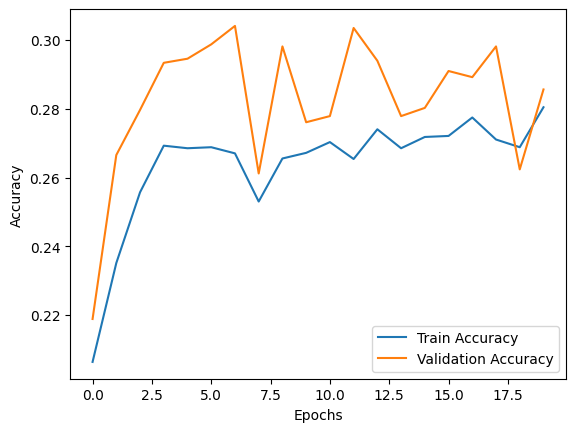

In [18]:
plt.plot(dnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(dnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [19]:
# Compute confusion matrix and ROC curve
from sklearn.preprocessing import label_binarize
def plot_confusion_matrix_and_roc(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    

    # Convert labels to one-hot encoding for multi-class AUC computation
    num_classes = len(label_encoder.classes_)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    # Compute AUC per class
    auc_per_class = roc_auc_score(y_true_bin, y_pred_prob, average=None)
    
    # Plot ROC Curve for each class
    plt.figure(figsize=(8,6))
    for i, class_label in enumerate(label_encoder.classes_):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f'{class_label} (AUC: {auc_per_class[i]:.2f})')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend()
    plt.show()

    # Print AUC for each class
    for i, class_label in enumerate(label_encoder.classes_):
        print(f"AUC for {class_label}: {auc_per_class[i]:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


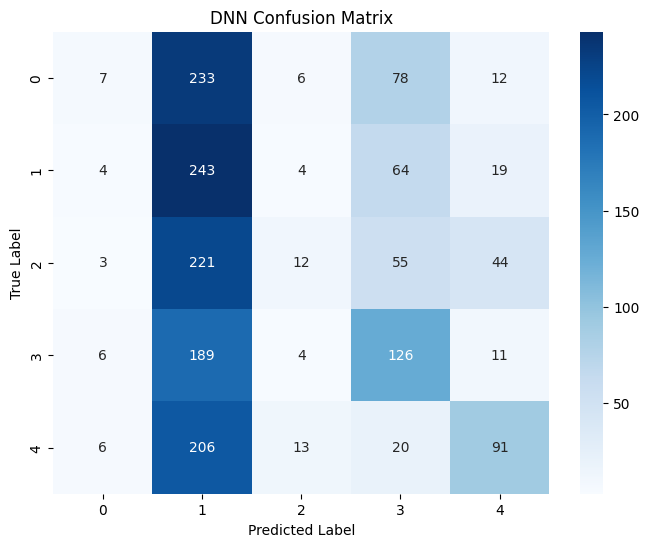

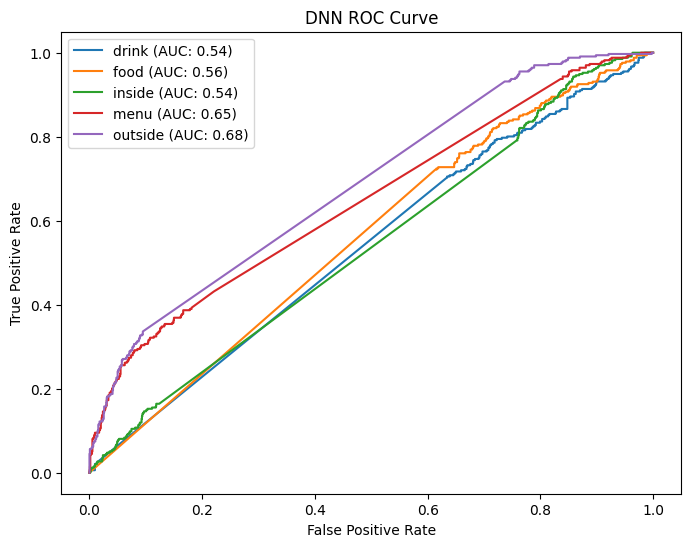

AUC for drink: 0.5386
AUC for food: 0.5584
AUC for inside: 0.5394
AUC for menu: 0.6473
AUC for outside: 0.6849


In [20]:
plot_confusion_matrix_and_roc(dnn_model, X_test, y_test, "DNN")

In [21]:
print("Shape of y_train:", y_train.shape)
print("Sample of y_train:", y_train[:5])


Shape of y_train: (6707, 5)
Sample of y_train: [[1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]


## Model Tuning. Prompt:

#### dnn_model = Sequential([
    Flatten(input_shape=(64, 64, 1)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])
#### dnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#### dnn_history = dnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

#### my model parameter is as above. how can I tune this parameter?

In [22]:
# DNN Model
dnn_model2 = Sequential([
    Flatten(input_shape=(64, 64, 1)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax') ## y_train.shape[1] provide the classes
])
dnn_model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
dnn2_history = dnn_model2.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.2191 - loss: 1.6620 - val_accuracy: 0.3041 - val_loss: 1.5723
Epoch 2/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.2503 - loss: 1.5904 - val_accuracy: 0.3077 - val_loss: 1.5484
Epoch 3/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.2786 - loss: 1.5637 - val_accuracy: 0.3089 - val_loss: 1.5209
Epoch 4/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.2911 - loss: 1.5470 - val_accuracy: 0.3208 - val_loss: 1.5040
Epoch 5/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.2941 - loss: 1.5340 - val_accuracy: 0.3309 - val_loss: 1.4974
Epoch 6/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.3140 - loss: 1.5254 - val_accuracy: 0.3321 - val_loss: 1.4910
Epoch 7/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.3239 - loss: 1.5107 - val_accuracy: 0.3584 - val_loss: 1.4718
Epoch 8/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3213 - loss: 1.5104 - val_ac

In [23]:
test_loss, test_acc = dnn_model2.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3930 - loss: 1.4118
Test Accuracy: 0.3930


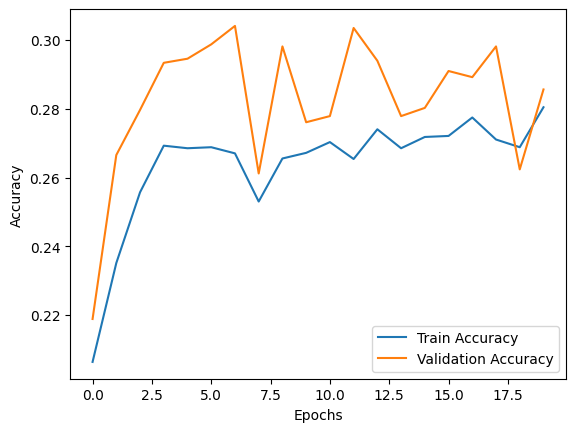

In [24]:
plt.plot(dnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(dnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


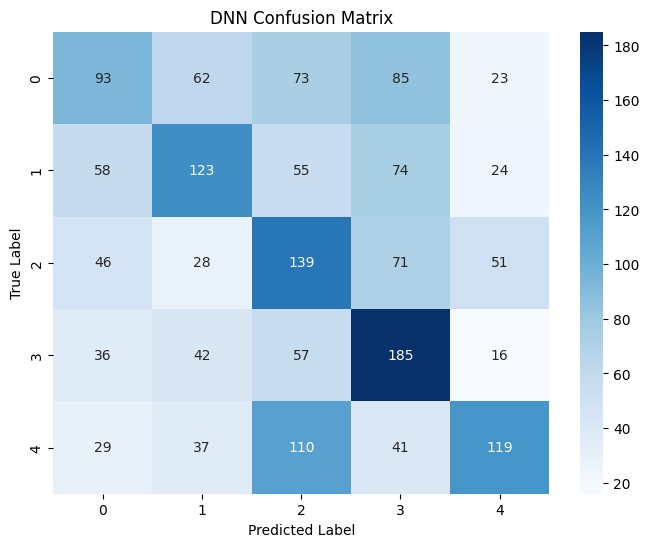

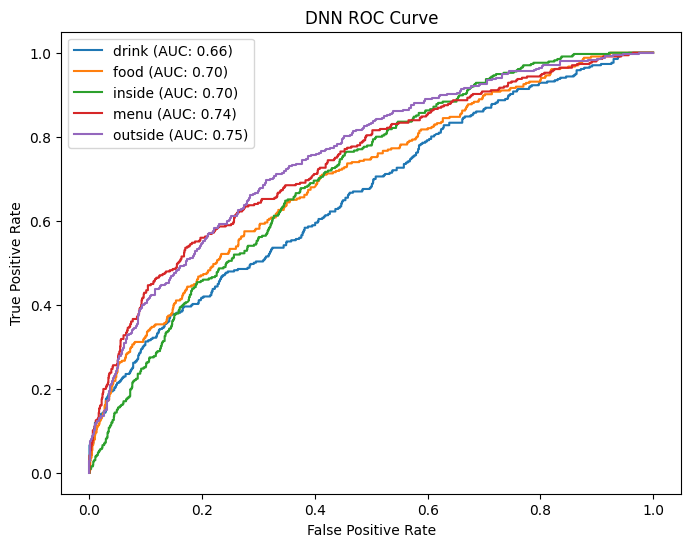

AUC for drink: 0.6626
AUC for food: 0.7020
AUC for inside: 0.7047
AUC for menu: 0.7402
AUC for outside: 0.7527


In [25]:
plot_confusion_matrix_and_roc(dnn_model2, X_test, y_test, "DNN")

In [26]:
# DNN Model
dnn_model3 = Sequential([
    Flatten(input_shape=(64, 64, 1)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax') ## y_train.shape[1] provide the classes
])
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
dnn_model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
dnn_model3_history = dnn_model3.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop])

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.2213 - loss: 1.6876 - val_accuracy: 0.2993 - val_loss: 1.5648
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.2745 - loss: 1.5860 - val_accuracy: 0.3238 - val_loss: 1.5335
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.2852 - loss: 1.5600 - val_accuracy: 0.3148 - val_loss: 1.5331
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.2978 - loss: 1.5485 - val_accuracy: 0.3172 - val_loss: 1.5085
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.3086 - loss: 1.5239 - val_accuracy: 0.3381 - val_loss: 1.4949
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3120 - loss: 1.5143 - val_accuracy: 0.3387 - val_loss: 1.4918
Epoch 7/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.3375 - loss: 1.5047 - val_accuracy: 0.3488 - val_loss: 1.4758
Epoch 8/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3413 - loss: 1.4872 - val_

In [27]:
test_loss, test_acc = dnn_model3.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4247 - loss: 1.3844
Test Accuracy: 0.4114


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


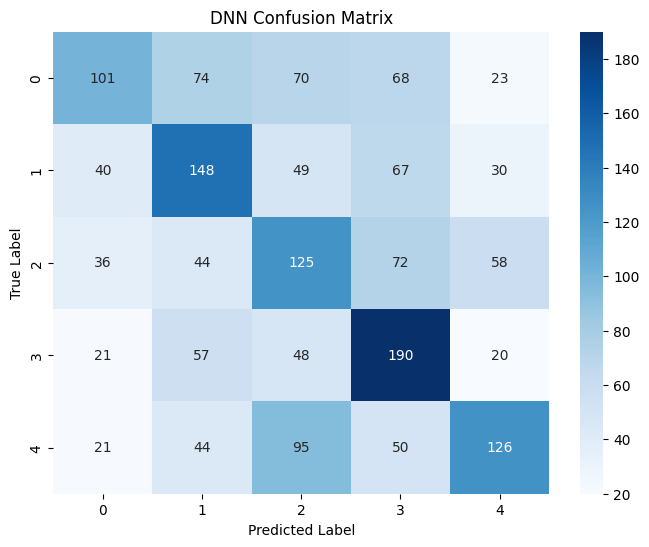

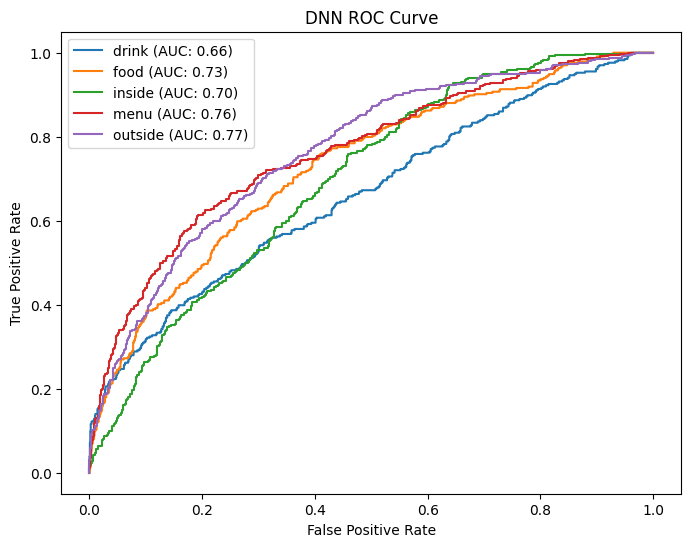

AUC for drink: 0.6623
AUC for food: 0.7287
AUC for inside: 0.6976
AUC for menu: 0.7638
AUC for outside: 0.7655


In [28]:
plot_confusion_matrix_and_roc(dnn_model3, X_test, y_test, "DNN")

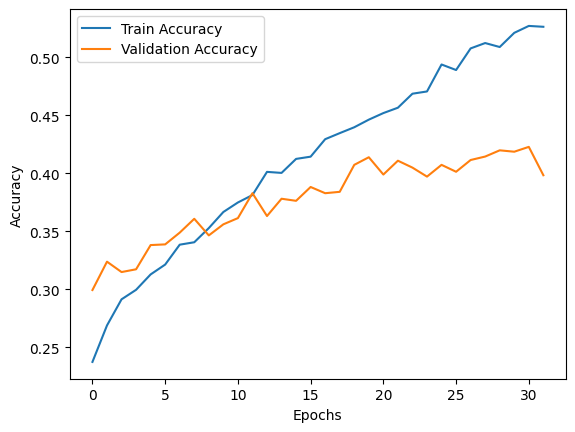

In [29]:
plt.plot(dnn_model3_history.history['accuracy'], label='Train Accuracy')
plt.plot(dnn_model3_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()